# Predicting Student Academic Success (Pass / Fail)
### CPE393 – Introduction to Data Science with Python | Final Group Project
**Dataset:** UCI / Kaggle "Student Performance" data set (Math course), `studentmat.csv`

## 1. Problem Definition and Goals



**Our problem statement:**
Schools want to identify, as early as possible, which students are at risk of failing a course so
that teachers can offer extra support before it is too late. We will treat this as a **binary
classification problem**: given information about a student (demographics, family background, study
habits, school support, social life), predict whether the student's final grade (`G3`) corresponds to
a **pass** or a **fail**.

- **Target variable:** a new binary column `pass`, derived from `G3` (final grade, 0–20 scale).
  We use the standard rule from the Portuguese grading system: `G3 >= 10` → pass (1), otherwise fail (0).
- **Why it matters:** if school-related and behavioural features (absences, study time, past
  failures, family support) can predict pass/fail reasonably well, schools could use similar models
  to flag at-risk students for tutoring, *without* needing to wait for the final exam.
- **Type of ML task:** supervised learning → binary classification.
- **Models we will compare:** Logistic Regression, Decision Tree, Random Forest (as proposed).


## 2. Import Libraries

- `pandas`: loads tabular data into a **DataFrame** (a table with labeled rows/columns) and gives us
  tools to filter, group, and transform it.
- `numpy`: fast numerical arrays and math operations; pandas is built on top of it.
- `matplotlib.pyplot` / `seaborn`: plotting. Matplotlib is the low-level engine; Seaborn is a
  higher-level wrapper that makes statistical plots (histograms, boxplots, heatmaps) easier and
  nicer-looking.
- `sklearn` (scikit-learn): the standard Python machine learning library. It gives us a consistent
  API (`.fit()`, `.predict()`) for preprocessing, models, and evaluation metrics.
- `random_state` / a fixed **seed**: Setting a fixed seed makes results **reproducible** — anyone re-running this notebook
  gets the exact same numbers.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)


## 3. Dataset Description


- **Source:** UCI Machine Learning Repository / Kaggle mirror, "Student Performance Data Set"
  (P. Cortez, Univ. Minho, 2008), Math class subset (`student-mat.csv`, here `studentmat.csv`).
- **License:** publicly available for research/education use; original paper: Cortez & Silva (2008),
  "Using Data Mining to Predict Secondary School Student Performance."
- **Size:** 395 rows (students), 33 columns (32 features + `G3`, the final grade).


In [ ]:


from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/student-mat.csv",
    sep=","
)

print("Shape (rows, columns):", df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape (rows, columns): (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

**Reading `df.info()`:** it tells us, per column, how many non-null values exist and the dtype
(`int64` = whole number, `object`/`string` = text/categorical).


## 4. Preprocessing and Cleaning

**Concept — the standard cleaning checklist for any tabular dataset:**
1. Missing values — do any cells have no data?
2. Duplicate rows — was the same record accidentally entered twice?
3. Incorrect / inconsistent data types — is a numeric column stored as text, or vice versa?
4. Outliers — are there implausible extreme values?
5. Unnecessary columns — IDs or constants that carry no information?

We check each one explicitly and **explain the decision**, per the assignment requirements — this is
graded, and "we didn't find any problems" is a perfectly valid, honest finding as long as you show
you actually checked.


In [ ]:
# 4.1 Missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing cells")
df.isnull().sum()[df.isnull().sum() > 0]   # will be empty if there is no missing data


Missing values per column:
0 total missing cells


,0


In [ ]:
# VERIFIE IF there is Duplicate rows
print("Numbr of exact duplicate rows:", df.duplicated().sum())


Number of exact duplicate rows: 0


In [ ]:
# Data types
df.dtypes


,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


**Decision:** all numeric columns (age, grades, study time, etc.) are already stored as integers.
 All categorical columns (school, sex, Mjob, reason, etc.) are stored as text/object.


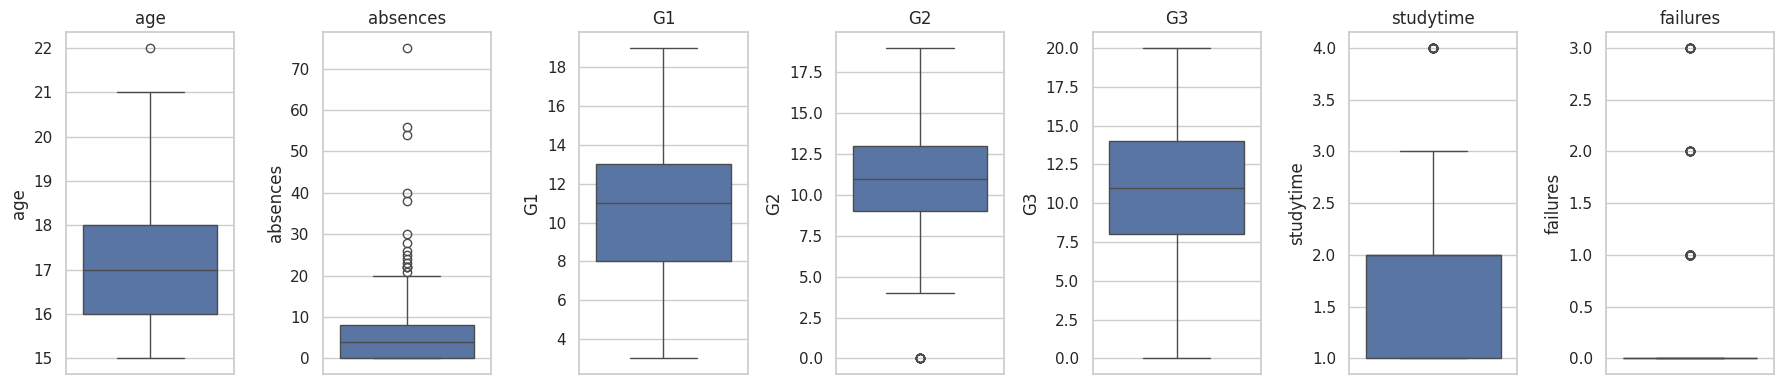

In [ ]:
# Outlier check on key numeric columns using boxplots
num_check = ["age", "absences", "G1", "G2", "G3", "studytime", "failures"]
fig, axes = plt.subplots(1, len(num_check), figsize=(18, 4))
for ax, col in zip(axes, num_check):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Interpretation:** `absences` has a right-skewed tail — a handful of students have far more
absences (20+) than the rest. `G3` shows a few zeros, which in this dataset represent students who
did not sit the final exam rather than a measurement error.

**Decision:** we keep these points. They are **valid, real values**, not data-entry mistakes
(no negative ages, no grades above 20, no negative absences), so removing them would throw away
genuine information about at-risk students — exactly the group this project cares about. Concept
note: an outlier should only be removed when it is implausible or a known data error, not simply
because it is extreme.


In [ ]:
#  Unnecessary columns
print("Any constant columns (no variation)?")
print([c for c in df.columns if df[c].nunique() == 1])


Any constant columns (no variation)?
[]


**Decision:** no constant columns, no ID-like columns. Nothing to drop at this stage.
